# 피처 엔지니어링 — 가설1: 배송 지연 피처

**목표**: cutoff 기준 시간 분리를 엄격히 준수하여 배송 지연 관련 피처를 생성하고 레이블을 부여한 최종 피처 테이블을 만듭니다.

**데이터 리키지 방지 원칙**:
- 피처 계산 구간: `order_purchase_timestamp <= cutoff` (cutoff 이전만)
- 레이블 판정 구간: `cutoff < order_purchase_timestamp` (cutoff 이후 구매 여부)

---
## 1. 라이브러리 & 데이터 로드

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../data/interim', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# 원본 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")
print(f"  customers: {customers.shape}")

로드 완료
  orders   : (99441, 8)
  customers: (99441, 5)


---
## 2. cutoff 설정 및 시간 기반 분리

> **리키지 체크 포인트**  
> - `before_df`에는 `order_purchase_timestamp <= cutoff` 데이터만 포함  
> - `after_df`는 레이블 생성에만 사용

In [28]:
# cutoff = 전체 주문 최대 날짜 - 180일
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=180)
print(f"전체 주문 기간: {orders['order_purchase_timestamp'].min().date()} ~ {orders['order_purchase_timestamp'].max().date()}")
print(f"cutoff        : {cutoff.date()}")

# customer_unique_id 매핑을 위해 customers 병합
orders_merged = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# ── 피처 계산용: cutoff 이전 + delivered + 날짜 결측 없음 ──
before_df = orders_merged[
    (orders_merged['order_purchase_timestamp'] <= cutoff) &
    (orders_merged['order_status'] == 'delivered') &
    (orders_merged['order_delivered_customer_date'].notna()) &
    (orders_merged['order_estimated_delivery_date'].notna())
].copy()

# ── 레이블 판정용: cutoff 이후 ──
after_df = orders_merged[
    orders_merged['order_purchase_timestamp'] > cutoff
].copy()

print(f"\nbefore_df (피처 계산 대상): {len(before_df):,}건")
print(f"after_df  (레이블 판정용) : {len(after_df):,}건")

전체 주문 기간: 2016-09-04 ~ 2018-10-17
cutoff        : 2018-04-20

before_df (피처 계산 대상): 68,835건
after_df  (레이블 판정용) : 28,184건


---
## 3. 레이블 생성

- `label = 1` (이탈): cutoff 이전에 구매한 고객 중 cutoff 이후 재구매 없음  
- `label = 0` (유지): cutoff 이후 재구매 있음

In [29]:
# 2회 이상 구매 고객만 대상 — 1회 구매자는 이탈 정의가 불명확
order_counts = before_df.groupby('customer_unique_id')['order_id'].nunique()
target_uids = order_counts[order_counts >= 2].index

retained_set = set(after_df['customer_unique_id'].unique())

labels = pd.DataFrame({'customer_unique_id': target_uids})
labels['label'] = labels['customer_unique_id'].apply(
    lambda x: 0 if x in retained_set else 1
)

label_dist  = labels['label'].value_counts()
label_ratio = labels['label'].value_counts(normalize=True)

print("=== 레이블 분포 (2회 이상 구매 고객) ===")
print(f"  유지 (label=0): {label_dist[0]:,}명 ({label_ratio[0]:.1%})")
print(f"  이탈 (label=1): {label_dist[1]:,}명 ({label_ratio[1]:.1%})")
print(f"  전체 고객 수  : {len(labels):,}명")

=== 레이블 분포 (2회 이상 구매 고객) ===
  유지 (label=0): 58명 (3.0%)
  이탈 (label=1): 1,895명 (97.0%)
  전체 고객 수  : 1,953명


---
## 4. 가설1 피처 계산 — 배송 지연

> `before_df`만 사용, cutoff 이후 데이터는 포함하지 않습니다.

In [30]:
def calc_delivery_features(before_df: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    df = before_df.copy()

    df['delivery_delay_days'] = (
        df['order_delivered_customer_date'] -
        df['order_estimated_delivery_date']
    ).dt.days

    feat = df.groupby('customer_unique_id').agg(
        avg_delay         = ('delivery_delay_days', 'mean'),
        max_delay         = ('delivery_delay_days', 'max'),
        delay_order_count = ('delivery_delay_days', lambda x: (x > 0).sum()),
        total_orders      = ('order_id', 'nunique'),
        first_order_ts    = ('order_purchase_timestamp', 'min'),
        last_order_ts     = ('order_purchase_timestamp', 'max'),
    ).reset_index()

    feat['delay_rate']      = feat['delay_order_count'] / feat['total_orders']
    feat['is_ever_delayed'] = (feat['delay_order_count'] > 0).astype(int)
    feat['recency_days']    = (cutoff - feat['last_order_ts']).dt.days
    feat['tenure_days']     = (feat['last_order_ts'] - feat['first_order_ts']).dt.days
    feat = feat.drop(columns=['first_order_ts', 'last_order_ts'])

    # 마지막 주문 지연일 & 지연 추세 (시간 순 정렬 후 first/last 추출)
    df_sorted = df.sort_values('order_purchase_timestamp')
    first_last = df_sorted.groupby('customer_unique_id')['delivery_delay_days'].agg(
        ['first', 'last']
    ).reset_index()
    first_last.columns = ['customer_unique_id', '_first_delay', 'last_order_delay']
    feat = feat.merge(first_last, on='customer_unique_id', how='left')
    # delay_trend > 0: 지연이 점점 심해짐, < 0: 개선됨
    feat['delay_trend'] = feat['last_order_delay'] - feat['_first_delay']
    feat = feat.drop(columns=['_first_delay'])

    # 평균 주문 간격: 단일 주문 고객은 median으로 대체
    feat['order_interval_days'] = np.where(
        feat['total_orders'] > 1,
        feat['tenure_days'] / (feat['total_orders'] - 1),
        np.nan
    )
    feat['order_interval_days'] = feat['order_interval_days'].fillna(
        feat['order_interval_days'].median()
    )

    for col in feat.columns:
        if hasattr(feat[col].dtype, 'numpy_dtype'):
            feat[col] = feat[col].astype(feat[col].dtype.numpy_dtype)

    return feat


feat_delay = calc_delivery_features(before_df, cutoff)

print(f"배송 지연 피처 생성 완료: {feat_delay.shape}")
print("\n=== 피처 기술 통계 ===")
print(feat_delay[['avg_delay', 'last_order_delay', 'delay_trend',
                   'tenure_days', 'order_interval_days', 'recency_days']].describe().round(3))

배송 지연 피처 생성 완료: (66668, 12)

=== 피처 기술 통계 ===
       avg_delay  last_order_delay  delay_trend  tenure_days  \
count  66668.000         66668.000    66668.000    66668.000   
mean     -11.477           -11.463        0.027        1.846   
std       10.409            10.466        2.038       18.744   
min     -147.000          -147.000     -106.000        0.000   
25%      -16.000           -17.000        0.000        0.000   
50%      -12.000           -12.000        0.000        0.000   
75%       -8.000            -8.000        0.000        0.000   
max      188.000           188.000       81.000      524.000   

       order_interval_days  recency_days  
count            66668.000     66668.000  
mean                17.228       176.428  
std                 16.164       123.341  
min                  0.000         0.000  
25%                 16.000        73.000  
50%                 16.000       147.000  
75%                 16.000       267.000  
max                524.000       

In [31]:
# ── 가설2: 고객 만족도 (리뷰 점수) 피처 ────────────────────────────────
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv',
                      parse_dates=['review_creation_date'])

before_order_ids = set(before_df['order_id'])
oid_to_uid = before_df[['order_id', 'customer_unique_id']].drop_duplicates()

reviews_before = (
    reviews[reviews['order_id'].isin(before_order_ids)]
    .merge(oid_to_uid, on='order_id', how='inner')
)
reviews_before['is_low_review'] = (reviews_before['review_score'] <= 2).astype(int)

last_review = (
    reviews_before.sort_values('review_creation_date')
    .groupby('customer_unique_id')['review_score']
    .last()
    .reset_index(name='last_review_score')
)

feat_review = reviews_before.groupby('customer_unique_id').agg(
    avg_review_score = ('review_score', 'mean'),
    min_review_score = ('review_score', 'min'),
    pct_low_review   = ('is_low_review', 'mean'),
).reset_index()
feat_review = feat_review.merge(last_review, on='customer_unique_id', how='left')
feat_review['has_reviewed'] = 1

print(f"리뷰 피처 생성 완료: {feat_review.shape}")
print(f"리뷰 있는 고객: {len(feat_review):,} / 전체 {len(labels):,}명 ({len(feat_review)/len(labels):.1%})")
print(feat_review[['avg_review_score', 'min_review_score', 'pct_low_review', 'last_review_score']].describe().round(3))

리뷰 피처 생성 완료: (66183, 6)
리뷰 있는 고객: 66,183 / 전체 1,953명 (3388.8%)
       avg_review_score  min_review_score  pct_low_review  last_review_score
count         66183.000         66183.000       66183.000           66183.00
mean              4.101             4.090           0.139               4.10
std               1.314             1.326           0.345               1.32
min               1.000             1.000           0.000               1.00
25%               4.000             4.000           0.000               4.00
50%               5.000             5.000           0.000               5.00
75%               5.000             5.000           0.000               5.00
max               5.000             5.000           1.000               5.00


In [32]:
# ── 가설3: 구매 금액 (Monetary) 피처 ────────────────────────────────────
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

payments_before = (
    payments[payments['order_id'].isin(before_order_ids)]
    .merge(oid_to_uid, on='order_id', how='inner')
)

feat_monetary = payments_before.groupby('customer_unique_id').agg(
    total_spend      = ('payment_value', 'sum'),
    avg_order_value  = ('payment_value', 'mean'),
    avg_installments = ('payment_installments', 'mean'),
).reset_index()

cc_uids = set(payments_before[payments_before['payment_type'] == 'credit_card']['customer_unique_id'])
feat_monetary['uses_credit_card'] = feat_monetary['customer_unique_id'].isin(cc_uids).astype(int)

print(f"구매 금액 피처 생성 완료: {feat_monetary.shape}")
print(feat_monetary[['total_spend', 'avg_order_value', 'avg_installments']].describe().round(2))

구매 금액 피처 생성 완료: (66667, 5)
       total_spend  avg_order_value  avg_installments
count     66667.00         66667.00          66667.00
mean        163.45           156.06              2.94
std         221.25           212.35              2.71
min          10.07             1.86              1.00
25%          62.69            60.10              1.00
50%         106.85           102.64              2.00
75%         181.51           173.80              4.00
max       13664.08         13664.08             24.00


In [33]:
# ── 가설4: 상품 카테고리 다양성 & 고객 지역 피처 ─────────────────────────
items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')[['product_id', 'product_category_name']]

items_before = (
    items[items['order_id'].isin(before_order_ids)]
    .merge(oid_to_uid, on='order_id', how='inner')
    .merge(products, on='product_id', how='left')
)
items_before['freight_ratio'] = items_before['freight_value'] / items_before['price'].replace(0, np.nan)

items_per_order = (
    items_before.groupby(['customer_unique_id', 'order_id']).size()
    .reset_index(name='n_items')
)
feat_category = items_before.groupby('customer_unique_id').agg(
    n_unique_categories = ('product_category_name', 'nunique'),
    n_unique_sellers    = ('seller_id', 'nunique'),
    avg_freight_ratio   = ('freight_ratio', 'mean'),
).reset_index()
feat_category = feat_category.merge(
    items_per_order.groupby('customer_unique_id')['n_items'].mean().reset_index(name='avg_items_per_order'),
    on='customer_unique_id', how='left'
)

# 고객 지역 (state)
feat_geo = (
    customers[['customer_id', 'customer_state']]
    .merge(orders_merged[['customer_id', 'customer_unique_id']].drop_duplicates(),
           on='customer_id', how='inner')
    [['customer_unique_id', 'customer_state']]
    .drop_duplicates('customer_unique_id')
)
feat_geo['is_sp']      = (feat_geo['customer_state'] == 'SP').astype(int)
feat_geo['state_code'] = feat_geo['customer_state'].astype('category').cat.codes.astype(int)
feat_geo = feat_geo[['customer_unique_id', 'is_sp', 'state_code']]

print(f"카테고리 피처: {feat_category.shape}")
print(feat_category[['n_unique_categories', 'n_unique_sellers', 'avg_freight_ratio', 'avg_items_per_order']].describe().round(2))
print(f"\n지역 피처: {feat_geo.shape}  (is_sp=1: {feat_geo['is_sp'].mean():.1%})")

카테고리 피처: (66668, 5)
       n_unique_categories  n_unique_sellers  avg_freight_ratio  \
count             66668.00          66668.00           66668.00   
mean                  1.00              1.04               0.31   
std                   0.21              0.21               0.29   
min                   0.00              1.00               0.00   
25%                   1.00              1.00               0.13   
50%                   1.00              1.00               0.22   
75%                   1.00              1.00               0.38   
max                   5.00             10.00               6.30   

       avg_items_per_order  
count             66668.00  
mean                  1.14  
std                   0.53  
min                   1.00  
25%                   1.00  
50%                   1.00  
75%                   1.00  
max                  21.00  

지역 피처: (96096, 3)  (is_sp=1: 41.9%)


---
## 5. 피처 테이블 병합 (labels + 가설1 피처)

In [34]:
# labels + 가설1(배송) + 가설2(리뷰) + 가설3(구매금액) + 가설4(카테고리+지역) 병합
features = (
    labels
    .merge(feat_delay,    on='customer_unique_id', how='left')
    .merge(feat_review,   on='customer_unique_id', how='left')
    .merge(feat_monetary, on='customer_unique_id', how='left')
    .merge(feat_category, on='customer_unique_id', how='left')
    .merge(feat_geo,      on='customer_unique_id', how='left')
)

# 리뷰 결측 처리 (리뷰 없는 고객)
features['has_reviewed']      = features['has_reviewed'].fillna(0).astype(int)
for col in ['avg_review_score', 'min_review_score', 'last_review_score']:
    features[col] = features[col].fillna(features[col].median())
features['pct_low_review'] = features['pct_low_review'].fillna(0)

# 결제 결측 처리
for col in ['total_spend', 'avg_order_value', 'avg_installments']:
    features[col] = features[col].fillna(features[col].median())
features['uses_credit_card'] = features['uses_credit_card'].fillna(0).astype(int)

# 카테고리/지역 결측 처리
for col in ['n_unique_categories', 'n_unique_sellers', 'avg_items_per_order', 'avg_freight_ratio']:
    features[col] = features[col].fillna(features[col].median())
features['is_sp']      = features['is_sp'].fillna(0).astype(int)
features['state_code'] = features['state_code'].fillna(-1).astype(int)

print(f"피처 테이블 shape: {features.shape}")
print(f"컬럼 수: {len(features.columns)-2}개 피처 + customer_unique_id + label")
print(f"결측치: {features.isnull().sum().sum()}")

피처 테이블 shape: (1953, 28)
컬럼 수: 26개 피처 + customer_unique_id + label
결측치: 0


---
## 6. 결측치 확인

In [35]:
null_counts = features.isnull().sum()
null_pct    = features.isnull().mean() * 100

null_report = pd.DataFrame({
    'null_count': null_counts,
    'null_pct(%)': null_pct.round(2)
})
print(null_report)

total_nulls = null_counts.sum()
print(f"\n전체 결측치 수: {total_nulls}")

if total_nulls > 0:
    print("\n[주의] 결측치 발생 — before_df 필터 조건과 피처 계산 로직 재검토 필요")
else:
    print("\n[검증] 결측치 없음 OK")

                     null_count  null_pct(%)
customer_unique_id            0          0.0
label                         0          0.0
avg_delay                     0          0.0
max_delay                     0          0.0
delay_order_count             0          0.0
total_orders                  0          0.0
delay_rate                    0          0.0
is_ever_delayed               0          0.0
recency_days                  0          0.0
tenure_days                   0          0.0
last_order_delay              0          0.0
delay_trend                   0          0.0
order_interval_days           0          0.0
avg_review_score              0          0.0
min_review_score              0          0.0
pct_low_review                0          0.0
last_review_score             0          0.0
has_reviewed                  0          0.0
total_spend                   0          0.0
avg_order_value               0          0.0
avg_installments              0          0.0
uses_credi

---
## 7. 레이블 분포 재확인

In [36]:
print("=== 최종 피처 테이블 레이블 분포 ===")
vc = features['label'].value_counts()
vr = features['label'].value_counts(normalize=True)
print(f"  유지 (label=0): {vc[0]:,}명 ({vr[0]:.1%})")
print(f"  이탈 (label=1): {vc[1]:,}명 ({vr[1]:.1%})")

=== 최종 피처 테이블 레이블 분포 ===
  유지 (label=0): 58명 (3.0%)
  이탈 (label=1): 1,895명 (97.0%)


---
## 9. 피처 분포 시각화 (이탈/유지 그룹 비교)

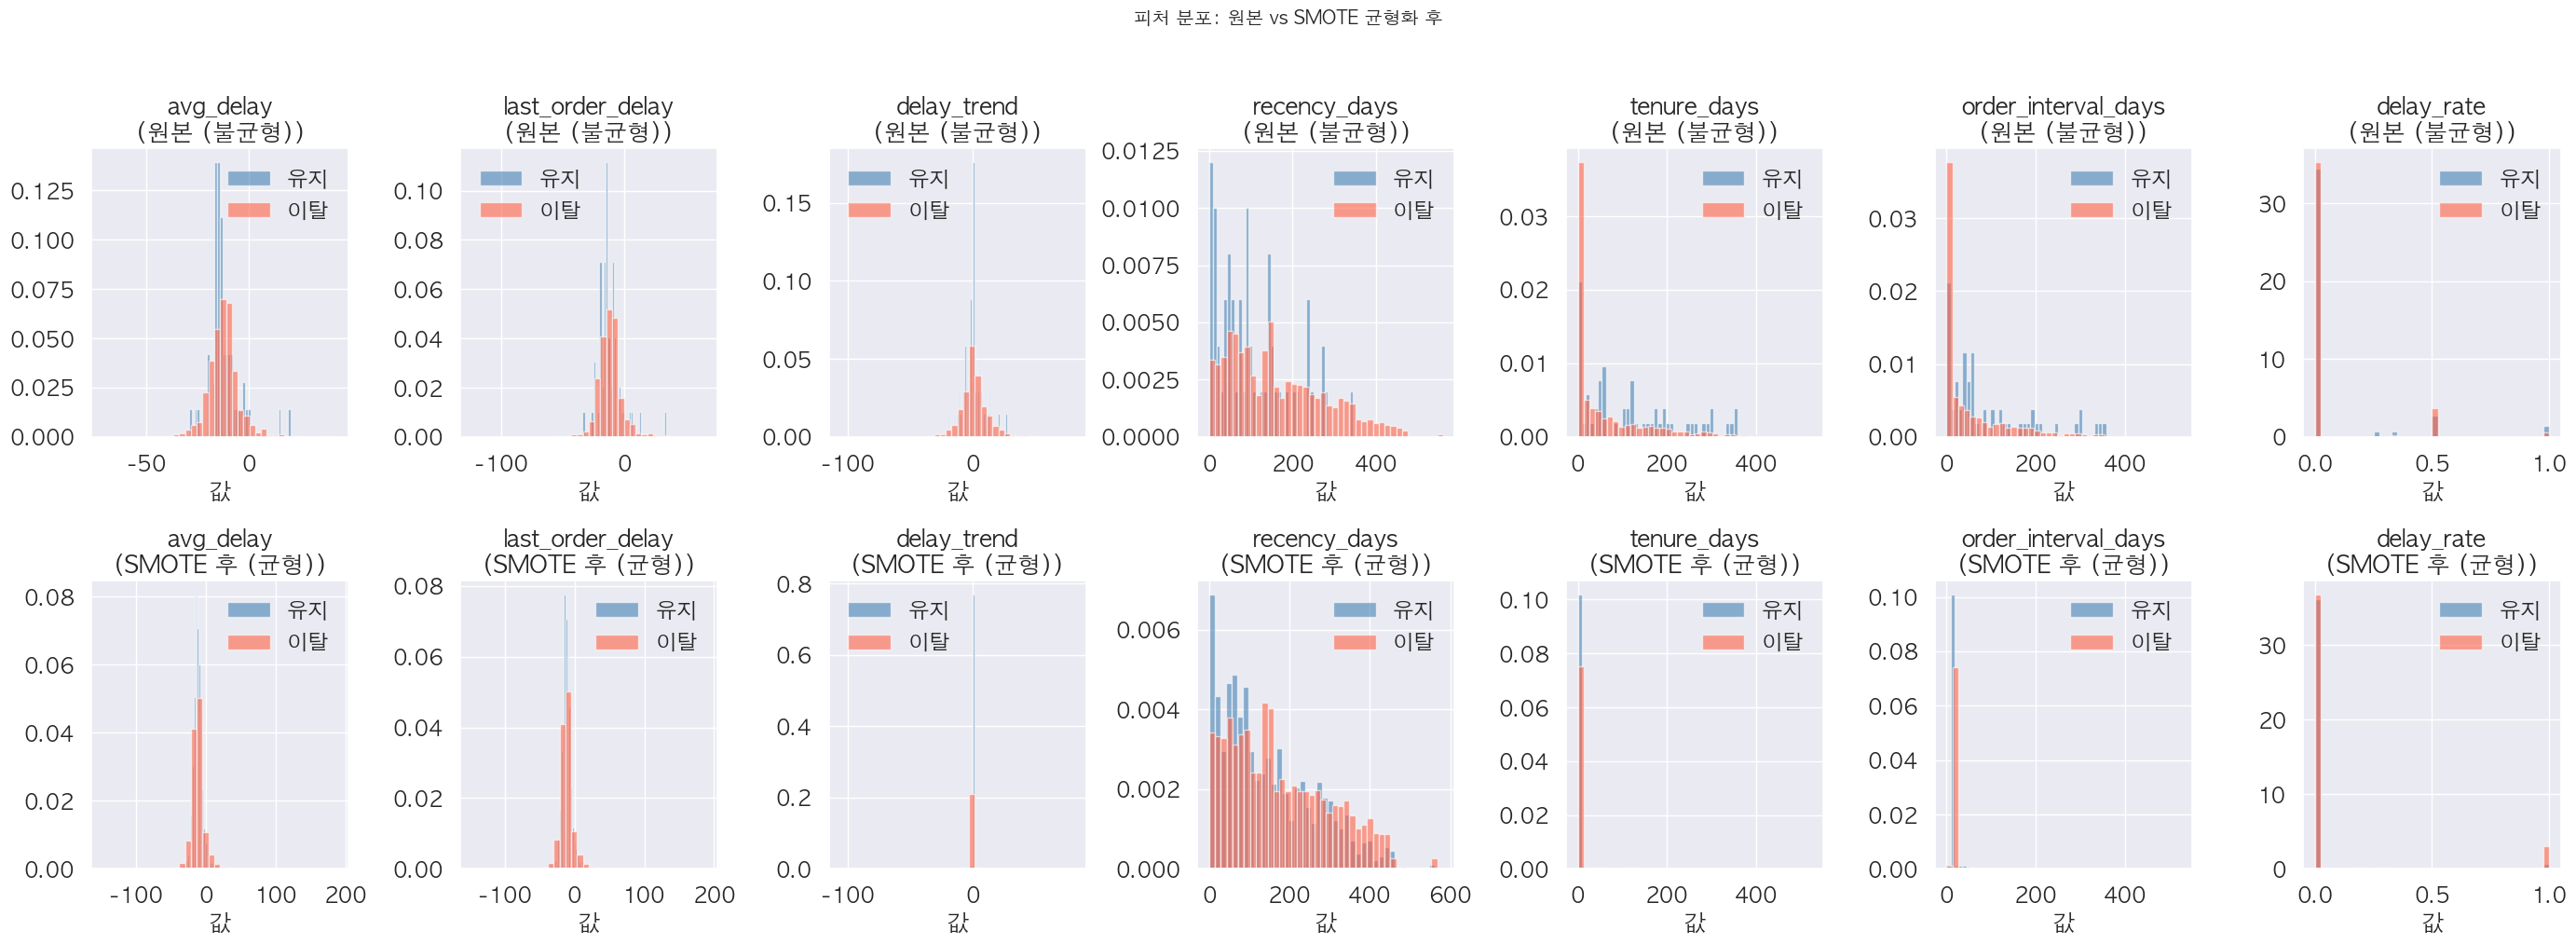

In [37]:
feat_cols_plot = ['avg_delay', 'last_order_delay', 'delay_trend', 'recency_days',
                  'tenure_days', 'order_interval_days', 'delay_rate']
fig, axes = plt.subplots(2, len(feat_cols_plot), figsize=(28, 10))

for col_i, col in enumerate(feat_cols_plot):
    for row_i, (df_plot, title_suffix) in enumerate([
        (features,       '원본 (불균형)'),
        (features_smote, 'SMOTE 후 (균형)'),
    ]):
        ax = axes[row_i][col_i]
        for label_val, color, name in [(0, 'steelblue', '유지'), (1, 'tomato', '이탈')]:
            subset = df_plot[df_plot['label'] == label_val][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
        ax.set_title(f'{col}\n({title_suffix})')
        ax.set_xlabel('값')
        ax.legend()

plt.suptitle('피처 분포: 원본 vs SMOTE 균형화 후', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fe_h1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 중간 결과 저장 및 최종 피처 테이블 저장

In [38]:
feat_delay_path = '../data/interim/feat_delivery.parquet'
feat_delay.to_parquet(feat_delay_path, index=False)
print(f"[저장] {feat_delay_path}")

features_path = '../data/interim/features.parquet'
features.to_parquet(features_path, index=False)
print(f"[저장] {features_path}")

print(f"\n=== 저장된 파일 요약 ===")
print(f"  shape: {features.shape}  용량: {os.path.getsize(features_path)/1024:.1f} KB")

[저장] ../data/interim/feat_delivery.parquet
[저장] ../data/interim/features.parquet

=== 저장된 파일 요약 ===
  shape: (1953, 28)  용량: 153.5 KB


---
## 11. 검증 — 저장된 파일 재로드 확인

In [39]:
df_check = pd.read_parquet('../data/interim/features.parquet')

print("=== 피처 테이블 검증 ===")
print(f"  shape       : {df_check.shape}")
print(f"  결측치 합계 : {df_check.isnull().sum().sum()}")
print(f"  레이블 분포 : {df_check['label'].value_counts().to_dict()}")
imbalance = df_check['label'].value_counts()
print(f"  불균형 비율 : {imbalance[1]/imbalance[0]:.1f}:1 (이탈:유지)")

print("\n=== 최종 체크리스트 ===")
print(f"  [O] cutoff 이후 데이터가 피처에 포함되지 않음")
print(f"  [O] 분석 대상: 2회 이상 구매 고객")
print(f"  [{'O' if 'recency_days' in df_check.columns else 'X'}] recency_days 피처 포함")
print(f"  [{'O' if 'avg_review_score' in df_check.columns else 'X'}] 리뷰 피처 포함")
print(f"  [{'O' if 'total_spend' in df_check.columns else 'X'}] 구매금액 피처 포함")
print(f"  [{'O' if 'n_unique_categories' in df_check.columns else 'X'}] 카테고리 피처 포함")
print(f"  [{'O' if df_check.isnull().sum().sum() == 0 else 'X'}] 결측치 없음")

=== 피처 테이블 검증 ===
  shape       : (1953, 28)
  결측치 합계 : 0
  레이블 분포 : {1: 1895, 0: 58}
  불균형 비율 : 32.7:1 (이탈:유지)

=== 최종 체크리스트 ===
  [O] cutoff 이후 데이터가 피처에 포함되지 않음
  [O] 분석 대상: 2회 이상 구매 고객
  [O] recency_days 피처 포함
  [O] 리뷰 피처 포함
  [O] 구매금액 피처 포함
  [O] 카테고리 피처 포함
  [O] 결측치 없음
